In [65]:
import os

import matplotlib.pyplot as plt

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

import numpy as onp
import numpy.typing as npt
import jax
import jax.numpy as jnp
from tqdm import tqdm
from typing import Callable

from gridops import set_up_grid_axis, GridAxis1D
from gridops import create_anterpolation_function

import sys

sys.path.append("/home/florian/PhD/work/code/msm_for_nn/")

from msmfornn.splines.nesting import compute_J_zeroplus


In [2]:
p = 4
order = p - 1

# Grid charge computation

In [3]:
length = 10.
h = 0.25
n_particles = 25

grid = set_up_grid_axis(length=length, h=h, p=p, periodic=False)

anterpolate = create_anterpolation_function(grid)
jitted_anterpolate = jax.jit(anterpolate)

In [4]:
rng = onp.random.default_rng(12345)
for _ in tqdm(range(100)):
    positions = jnp.array(rng.uniform(0.0, length, size=n_particles))
    charges = jnp.array(rng.uniform(-1., 1., size=n_particles))

    # Call to trigger compilation
    gridcharge, _, _ = jitted_anterpolate(positions, charges)
    # Second call
    gridcharge, _, _ = jitted_anterpolate(positions, charges)

    assert jnp.allclose(gridcharge.sum(), charges.sum())

100%|██████████| 100/100 [00:01<00:00, 67.57it/s]


In [5]:
gridcharge

Array([ 0.00000000e+00, -2.20895703e-02, -7.21955552e-02,  4.26507768e-01,
        3.29568189e-01,  7.23824047e-03,  2.32713530e-04,  1.03667146e-01,
        2.66392054e-01,  4.21979956e-02,  6.74068875e-03,  3.30153620e-01,
        4.79153039e-01, -3.06775366e-01, -2.94411676e-01, -7.74144703e-02,
       -1.09600666e-01, -1.56720723e-01, -3.66969234e-01, -2.74730081e-01,
       -3.35428598e-02, -2.99325842e-02, -2.56905306e-03, -1.49392044e-02,
       -2.21182511e-01, -1.69071643e-01, -4.28063705e-03, -1.13500813e-03,
       -5.80471872e-02, -4.15888721e-01, -5.20213559e-01,  1.03357089e-01,
        2.07316078e-01, -1.67594088e-01, -6.81575186e-01, -1.51845703e-01,
        0.00000000e+00,  3.62461835e-03,  1.75952112e-01,  2.55234466e-01,
        2.91401722e-01,  5.84573301e-01,  1.23826059e-01,  4.11681290e-04,
        0.00000000e+00], dtype=float64)

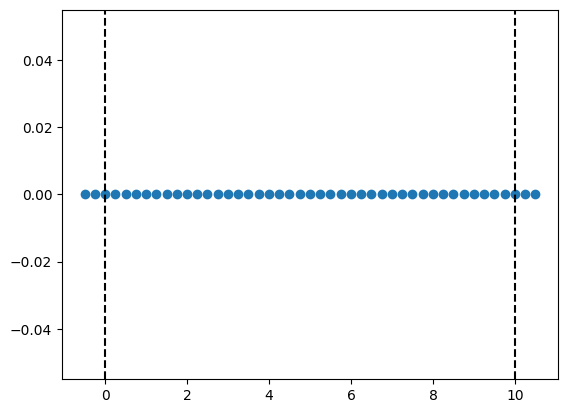

In [6]:
points = (onp.arange(grid.n_total) - p // 2) * grid.h

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')
ax.scatter(points, onp.zeros_like(points))


In [7]:
# TODO: compute grid charge for a particle very close to upper domain bound -> I think the grid is currently too small in that case!

pos_appended = jnp.concatenate([positions, jnp.array([10.])])
charges_appended = jnp.concatenate([charges, jnp.array([0.6])])
gc, _, _ = anterpolate(pos_appended, charges_appended)

assert jnp.allclose(gc.sum(), charges_appended.sum())

In [8]:
gc = grid.get_gridindices_and_splinevals(jnp.array([10.]))
gc

(Array([40, 41, 42, 43], dtype=int64),
 Array([0.        , 0.16666667, 0.66666667, 0.16666667], dtype=float64))

In [9]:
gc = grid.get_gridindices_and_splinevals(jnp.array([10. - 1.e-6]))
gc

(Array([40, 41, 42, 43], dtype=int64),
 Array([1.06666666e-17, 1.66668667e-01, 6.66666667e-01, 1.66664667e-01],      dtype=float64))

In [10]:
int(onp.ceil(length / h))

40

In [11]:
grid.n_domain

41

In [12]:
grid.length, grid.h

(10.0, 0.25)

# Construction of grids

In [13]:
length = 10.0
max_gridlevel = 4

grids_all_levels = [None]  # there is no grid at level zero
for l in range(1, max_gridlevel + 1):
    h = length / (2 ** (max_gridlevel - l))
    print(l, h)
    grid = set_up_grid_axis(length=length, h=h, p=p, periodic=False)
    grids_all_levels.append(grid)

1 1.25
2 2.5
3 5.0
4 10.0


In [14]:
grids_all_levels

[None,
 GridAxis1D(periodic=False, length=10.0, h=1.25, n_domain=9, n_total=13, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fdaa8350160>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fdaa8350f70>),
 GridAxis1D(periodic=False, length=10.0, h=2.5, n_domain=5, n_total=9, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fdaa8350ca0>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fdaa83508b0>),
 GridAxis1D(periodic=False, length=10.0, h=5.0, n_domain=3, n_total=7, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fdaa82e2040>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fdaa8350d30>),
 GridAxis1D(periodic=False, length=10.0, h=10.0, n_domain=2, n_total=6, process_raw_indices=<func

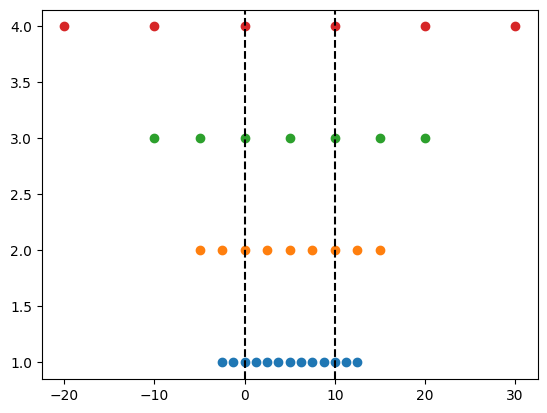

In [15]:
points_all_levels = [None]

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l, g in enumerate(grids_all_levels):
    if l == 0:
        continue
    points = (onp.arange(g.n_total) - p // 2) * g.h
    points_all_levels.append(points)
    ax.scatter(points, onp.zeros_like(points) + l)


In [16]:
def shift(m: npt.ArrayLike):
    return m - p // 2


def unshift(m: int):
    return m + p // 2

In [17]:
m_raw = 2
n_raw = shift(onp.arange(len(points_all_levels[1])))

In [114]:
n_raw

array([-2, -1,  0,  1,  2,  3,  4,  5,  6])

In [115]:
onp.abs(n_raw - 2 * m_raw)

array([8, 7, 6, 5, 4, 3, 2, 1, 0])

In [116]:
onp.abs(n_raw - 2 * m_raw) <= p // 2

array([False, False, False, False, False, False,  True,  True,  True])

In [117]:
onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)[0]

array([6, 7, 8])

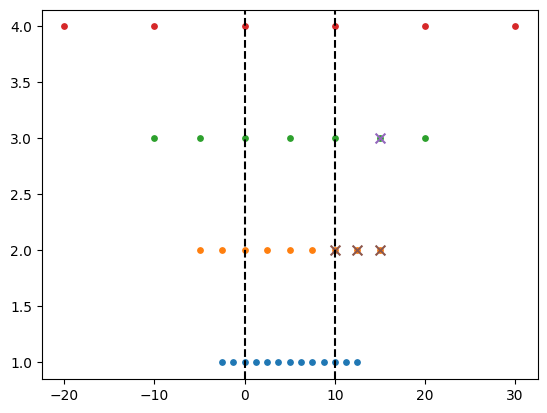

In [22]:
fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l in range(1, max_gridlevel + 1):
    g = grids_all_levels[l]
    points = points_all_levels[l]
    ax.scatter(points, onp.full_like(points, l), s=15)

l = 3
m_raw = 3
n_raw = shift(onp.arange(len(points_all_levels[l - 1])))
is_in_bounds = onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)
n_raw_selected = n_raw[is_in_bounds]

ax.scatter(points_all_levels[l][unshift(m_raw)], l, marker="x", s=50)
ax.scatter(points_all_levels[l - 1][unshift(n_raw_selected)],
           onp.full_like(n_raw_selected, l - 1), marker="x", s=50)

# Restriction

In [32]:
n_total = grids_all_levels[l - 1].n_total
gridcharge_below = onp.full(n_total, 1.234)  # TODO

n_raw_lower = 2 * m_raw - p // 2
n_raw_upper = 2 * m_raw + p // 2
n_lower = unshift(n_raw_lower)
n_upper = unshift(n_raw_upper)

n_selected = onp.arange(n_lower, n_upper + 1)
is_in_bounds = onp.logical_and(n_selected >= 0, n_selected < n_total)
intentionally_out_of_bounds_index = n_total + 1
n_selected = onp.where(is_in_bounds, n_selected,
                       intentionally_out_of_bounds_index)
n_selected

array([ 6,  7,  8, 10, 10])

In [25]:
jnp.array(gridcharge_below).at[n_selected].get(mode="fill", fill_value=0.0)

Array([1.234, 1.234, 1.234, 0.   , 0.   ], dtype=float64)

In [50]:
def get_gridinds_one_below(m_raw):
    n_raw_lower = 2 * m_raw - p // 2
    n_lower = unshift(n_raw_lower)
    n_selected = n_lower + jnp.arange(p + 1)

    return n_selected


In [51]:
get_gridinds_one_below(-2)

Array([-4, -3, -2, -1,  0], dtype=int64)

In [52]:
raw_ms = jnp.arange(grids_all_levels[l].n_total) - p // 2
raw_ms

Array([-2, -1,  0,  1,  2,  3,  4], dtype=int64)

In [88]:
J_zeroplus = compute_J_zeroplus(p)
J = onp.concatenate((J_zeroplus[::-1][:-1], J_zeroplus))
J

array([0.125, 0.5  , 0.75 , 0.5  , 0.125])

In [87]:
inds = jax.vmap(get_gridinds_one_below)(raw_ms)
in_bounds = onp.logical_and(inds >= 0, inds < n_total)
intentionally_out_of_bounds_index = n_total + 1
inds = onp.where(in_bounds, inds, intentionally_out_of_bounds_index)

selected_gc = jnp.array(gridcharge_below).at[inds].get(mode="fill", fill_value=0.0)
selected_gc

Array([[0.   , 0.   , 0.   , 0.   , 1.234],
       [0.   , 0.   , 1.234, 1.234, 1.234],
       [1.234, 1.234, 1.234, 1.234, 1.234],
       [1.234, 1.234, 1.234, 1.234, 1.234],
       [1.234, 1.234, 1.234, 1.234, 1.234],
       [1.234, 1.234, 1.234, 0.   , 0.   ],
       [1.234, 0.   , 0.   , 0.   , 0.   ]], dtype=float64)

In [89]:
selected_gc * J 

Array([[0.     , 0.     , 0.     , 0.     , 0.15425],
       [0.     , 0.     , 0.9255 , 0.617  , 0.15425],
       [0.15425, 0.617  , 0.9255 , 0.617  , 0.15425],
       [0.15425, 0.617  , 0.9255 , 0.617  , 0.15425],
       [0.15425, 0.617  , 0.9255 , 0.617  , 0.15425],
       [0.15425, 0.617  , 0.9255 , 0.     , 0.     ],
       [0.15425, 0.     , 0.     , 0.     , 0.     ]], dtype=float64)

In [104]:
def make_restriction_function(grid: GridAxis1D,
                              grid_below: GridAxis1D,
                              J: npt.ArrayLike) -> Callable:
    # TODO: how should p be passed/inferred?
    
    J = jnp.asarray(J)

    def get_gridinds_one_below(m_raw: float) -> jax.Array:
        n_raw_selected = (2 * m_raw - p // 2) + jnp.arange(p + 1)
        n_selected = grid_below.process_raw_indices(n_raw_selected)
        return n_selected

    if grid.periodic:
        raise  # TODO: not implemented
    else:
        # TODO: should this be handled by a generic grid function as well? (how?)
        raw_ms = jnp.arange(grid.n_total) - p // 2
        ms = grid.process_raw_indices(raw_ms)

    def apply_restrict(gridcharge_below: jax.Array) -> jax.Array:
        selected_ns = jax.vmap(get_gridinds_one_below)(raw_ms)
        is_in_bounds = jnp.logical_and(selected_ns >= 0,
                                       selected_ns < grid_below.n_total)
        intentionally_out_of_bounds_index = grid_below.n_total + 1
        selected_ns = jnp.where(is_in_bounds, selected_ns,
                                intentionally_out_of_bounds_index)
        selected_gridcharges_below = gridcharge_below.at[selected_ns].get(
            mode="fill", fill_value=0.0)
        
        
        gridcharge = jnp.zeros(grid.n_total)
        gridcharge = gridcharge.at[ms].add((selected_gridcharges_below * J).sum(axis=1))
        
        return gridcharge

    return apply_restrict

In [105]:
restrict = make_restriction_function(grid=grids_all_levels[l], grid_below=grids_all_levels[l-1], J=J)
jitted_restrict = jax.jit(restrict)

In [106]:
restrict(jnp.asarray(gridcharge_below))

Array([0.15425, 1.69675, 2.468  , 2.468  , 2.468  , 1.69675, 0.15425],      dtype=float64)

In [108]:
jitted_restrict(jnp.asarray(gridcharge_below))
jitted_restrict(jnp.asarray(gridcharge_below))

Array([0.15425, 1.69675, 2.468  , 2.468  , 2.468  , 1.69675, 0.15425],      dtype=float64)

In [109]:
gc_restricted = jitted_restrict(jnp.asarray(gridcharge_below))

In [113]:
jnp.isclose(gridcharge_below.sum(), gc_restricted.sum())

Array(True, dtype=bool)

## Compare grid charges computed via restriction with directly computed ones

In [158]:
n_particles = 15

rng = onp.random.default_rng(8439293)
xs = rng.uniform(0., length, size=n_particles)
qs = rng.uniform(-1., 1., size=n_particles)

In [159]:
anterpolation_funcs_all_levels = [None] + [jax.jit(create_anterpolation_function(g)) for g in grids_all_levels[1:]]

In [160]:
gridcharges_direct = [None] + [af(xs, qs)[0] for af in anterpolation_funcs_all_levels[1:]]

In [162]:
restriction_funcs_all_levels = [None, None]
for l in range(2, len(grids_all_levels)):
    rf = make_restriction_function(grids_all_levels[l], grids_all_levels[l-1], J)
    rf = jax.jit(rf)
    restriction_funcs_all_levels.append(rf)

In [163]:
gridcharges_via_restriction = [None, None]

for l in range(2, len(grids_all_levels)):
    rf = restriction_funcs_all_levels[l]
    gc_lowergrid = gridcharges_direct[l - 1]
    gc = rf(gc_lowergrid)
    gridcharges_via_restriction.append(gc)

In [164]:
gridcharges_direct

[None,
 Array([ 0.        ,  0.16816469,  0.98879601,  1.32684054,  0.82799407,
         0.74232284, -0.10068483, -0.11852558,  0.67924506, -0.56404249,
        -0.52137194, -0.02400572,  0.        ], dtype=float64),
 Array([ 0.        ,  0.20768184,  1.59259888,  1.76659114,  0.4247899 ,
         0.09039267, -0.60014742, -0.07717435,  0.        ], dtype=float64),
 Array([ 0.        ,  0.30291578,  2.23468439,  1.37114076, -0.39040267,
        -0.11360561,  0.        ], dtype=float64),
 Array([ 0.        ,  0.43079344,  2.46424123,  0.61530112, -0.10560314,
         0.        ], dtype=float64)]

In [165]:
gridcharges_via_restriction

[None,
 None,
 Array([ 0.        ,  0.20768184,  1.59259888,  1.76659114,  0.4247899 ,
         0.09039267, -0.60014742, -0.07717435,  0.        ], dtype=float64),
 Array([ 0.        ,  0.30291578,  2.23468439,  1.37114076, -0.39040267,
        -0.11360561,  0.        ], dtype=float64),
 Array([ 0.        ,  0.43079344,  2.46424123,  0.61530112, -0.10560314,
         0.        ], dtype=float64)]

In [166]:
for gc_direct, gc_restrict in zip(gridcharges_direct[2:], gridcharges_via_restriction[2:]):
    assert jnp.allclose(gc_direct, gc_restrict)